<a href="https://colab.research.google.com/github/Gyanam1310/Black-Friday-Sales-EDA/blob/master/SVC_MUSHROOM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

data = pd.read_csv('mushrooms.csv')

In [6]:
data.head()

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g


In [7]:
data.isna().sum()

,0
class,0
cap-shape,0
cap-surface,0
cap-color,0
bruises,0
odor,0
gill-attachment,0
gill-spacing,0
gill-size,0
gill-color,0


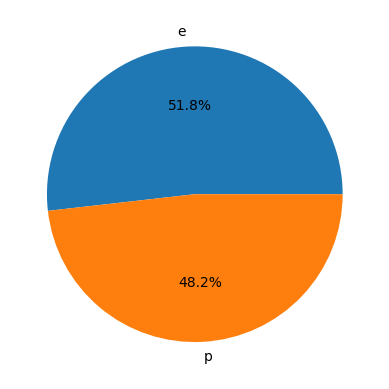

In [13]:
count = data['class'].value_counts()
plt.pie(count, labels=count.index, autopct='%1.1f%%')
plt.show()

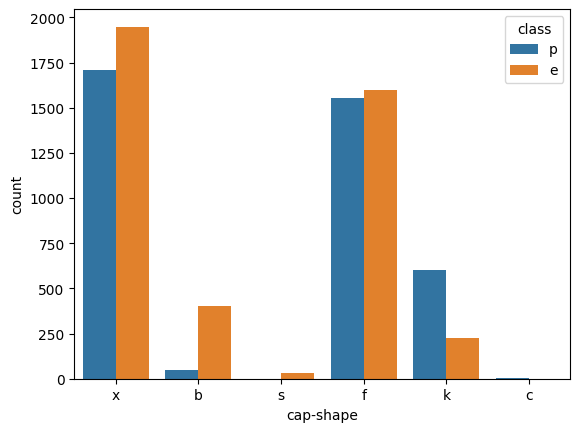

In [11]:
sns.countplot(data=data, x='cap-shape', hue='class')
plt.show()

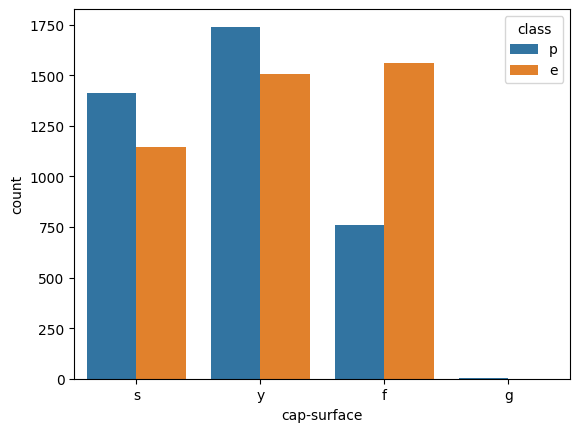

In [14]:
sns.countplot(data=data, x='cap-surface', hue='class')
plt.show()

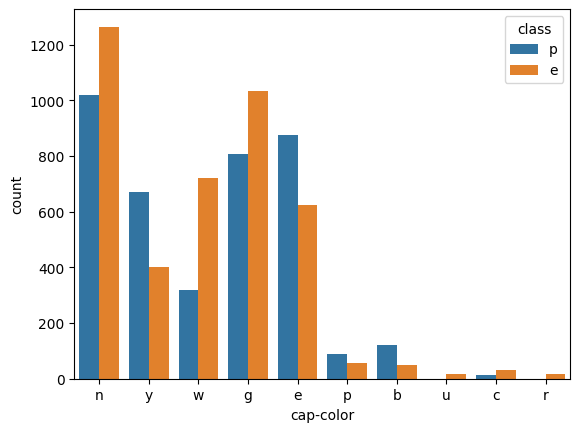

In [15]:
sns.countplot(data=data, x='cap-color', hue='class')
plt.show()

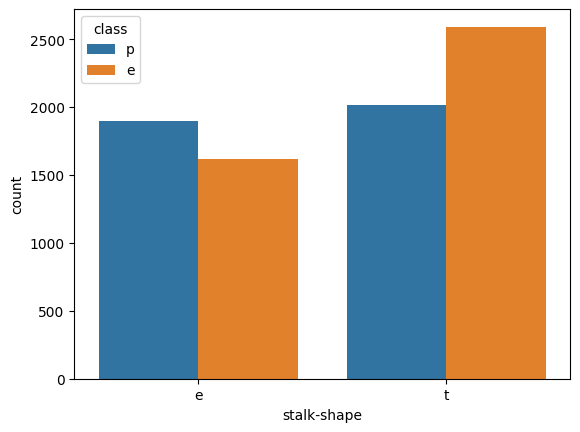

In [16]:
sns.countplot(data=data, x='stalk-shape', hue='class')
plt.show()

In [21]:
X = data.drop(['class'], axis=1)
y = data['class']

#Label Encoding

In [24]:
from sklearn.preprocessing import LabelEncoder

X_enc = X

for col in X.columns:
  lb = LabelEncoder()
  X_enc[col] = lb.fit_transform(X[col])

y_enc = lb.fit_transform(y)

In [25]:
X_enc.head(5)

,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,stalk-shape,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,5,2,4,1,6,1,0,1,4,0,...,2,7,7,0,2,1,4,2,3,5
1,5,2,9,1,0,1,0,0,4,0,...,2,7,7,0,2,1,4,3,2,1
2,0,2,8,1,3,1,0,0,5,0,...,2,7,7,0,2,1,4,3,2,3
3,5,3,8,1,6,1,0,1,5,0,...,2,7,7,0,2,1,4,2,3,5
4,5,2,3,0,5,1,1,0,4,1,...,2,7,7,0,2,1,0,3,0,1


In [27]:
y_enc

array([1, 0, 0, ..., 0, 1, 0])

In [28]:
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_enc, y_enc, test_size=0.2, random_state=42)

svc = SVC()
svc.fit(X_train, y_train)
print(svc.score(X_test, y_test))

0.9926153846153846


In [29]:
print(svc.score(X_train, y_train))

0.9898445914756117
